# <center>MDSA D212 Data Mining II</center> 

## <center>Task 3  Association Rules And Lift Analysis</center>

## <center>Justin Jordan</center>

## <center>7/12/2026</center>

## <center>WGU</center>



### Scenario 1
One of the most critical factors in customer relationship management that directly affects a company’s long-term profitability is understanding the customers. When a company can better understand its customers’ characteristics, it is better able to target products and marketing campaigns for customers, resulting in better profits for the company in the long term.



You are an analyst for a telecommunications company that wants to better understand the characteristics of its customers. You have been asked to perform a market basket analysis to analyze customer data to identify key associations of your customer purchases, ultimately enabling better business and strategic decision-making.

## Part I: Research Question

### A.  Describe the purpose of your data mining report by doing the following:

1.  Propose one question relevant to a real-world organizational situation that you will answer using market basket analysis.

    -  What items do customers frequently purchase together?  By answering this question, we can recommend items to customers and better understand purchasing habits.     

2.  Define one goal of the data analysis. Ensure your goal is reasonable within the scope of the selected scenario and is represented in the available data.
    - One goal of this analysis is to identify items that could be bundled together to increase company revenue.  Another goal would be to  uncover patterns within the data set to find items that are purchased together frequently.        

## Part II: Market Basket Justification

### B.   Explain the reasons for using market basket analysis by doing the following:

1.  Explain how market basket analyzes the selected data set. Include expected outcomes.
    -   Market Basket Analysis(MBA) is a data mining technique used to uncover purchase patterns.  It involves analyzing the combinations of products that are bought together(GeekforGeeks, 2025).  The data set will be cleaned and transformed into a format where each transaction and column has a value for each item.  Association rules will be generated based on the frequency of the items.  Once generated, they can be evaluated using metrics such as confidence, lift and support.  These metrics will be used to help identify purchase patterns.  One expected outcome would be to identify frequently purchased items and the association rules between the items.  The insight gained will be helpful for better business and strategic decision making to better target products and marketing campaigns.   

2.  Provide one example of transactions in the data set.
    -  One example transaction from the data set: 
        - Logitech M510 Wireless mouse	HP 63 Ink	HP 65 ink	nonda USB C to USB Adapter	10ft iPHone Charger Cable	HP 902XL ink	Creative Pebble 2.0 Speakers	Cleaning Gel Universal Dust Cleaner	Micro Center 32GB Memory card	YUNSONG 3pack 6ft Nylon Lightning Cable	TopMate C5 Laptop Cooler pad	Apple USB-C Charger cable	HyperX Cloud Stinger Headset	TONOR USB Gaming Microphone	Dust-Off Compressed Gas 2 pack	3A USB Type C Cable 3 pack 6FT	HOVAMP iPhone charger	SanDisk Ultra 128GB card	FEEL2NICE 5 pack 10ft Lighning cable	FEIYOLD Blue light Blocking Glasses
          

3.  Summarize one assumption of market basket analysis.
    -  One assumption of MBA is Transaction Independence.  This means transactions are assumed to be independent of each other.  If transactions are not independent, it might impact the reliability of the association rules generated(Deniran, 2023).
        
        

## Part III: Data Preparation and Analysis

### C.  Prepare and perform market basket analysis by doing the following:

1.  Transform the data set to make it suitable for market basket analysis. Include a copy of the cleaned data set.
  


In [74]:
#c1 code

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
teleco = pd.read_csv("C:/users/jjord/Documents/WGU/D212/d212_pa3/teleco_market_basket.csv")

# Profile of Data Frame
teleco.head()

,Item01,Item02,Item03,Item04,Item05,Item06,Item07,Item08,Item09,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Logitech M510 Wireless mouse,HP 63 Ink,HP 65 ink,nonda USB C to USB Adapter,10ft iPHone Charger Cable,HP 902XL ink,Creative Pebble 2.0 Speakers,Cleaning Gel Universal Dust Cleaner,Micro Center 32GB Memory card,YUNSONG 3pack 6ft Nylon Lightning Cable,TopMate C5 Laptop Cooler pad,Apple USB-C Charger cable,HyperX Cloud Stinger Headset,TONOR USB Gaming Microphone,Dust-Off Compressed Gas 2 pack,3A USB Type C Cable 3 pack 6FT,HOVAMP iPhone charger,SanDisk Ultra 128GB card,FEEL2NICE 5 pack 10ft Lighning cable,FEIYOLD Blue light Blocking Glasses
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Apple Lightning to Digital AV Adapter,TP-Link AC1750 Smart WiFi Router,Apple Pencil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
teleco.shape

(15002, 20)

In [76]:
teleco=teleco[teleco['Item01'].notna()]
teleco.shape

(7501, 20)

In [77]:
#convert to list
rows =[]
for i in range (0,7501):
                rows.append([str(teleco.values[i,j])
                    for j in range(0,20)])

In [78]:
#array
TE = TransactionEncoder()
array = TE.fit(rows).transform(rows)

# dataframe
trans = pd.DataFrame(array, columns = TE.columns_)

In [79]:
trans

,10ft iPHone Charger Cable,10ft iPHone Charger Cable 2 Pack,3 pack Nylon Braided Lightning Cable,3A USB Type C Cable 3 pack 6FT,5pack Nylon Braided USB C cables,ARRIS SURFboard SB8200 Cable Modem,Anker 2-in-1 USB Card Reader,Anker 4-port USB hub,Anker USB C to HDMI Adapter,Apple Lightning to Digital AV Adapter,...,iFixit Pro Tech Toolkit,iPhone 11 case,iPhone 12 Charger cable,iPhone 12 Pro case,iPhone 12 case,iPhone Charger Cable Anker 6ft,iPhone SE case,nan,nonda USB C to USB Adapter,seenda Wireless mouse
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7497,False,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [80]:
#drop empty(NaN) columns
teleco_clean = trans.drop(['nan'], axis=1)
teleco_clean.head(7501)

,10ft iPHone Charger Cable,10ft iPHone Charger Cable 2 Pack,3 pack Nylon Braided Lightning Cable,3A USB Type C Cable 3 pack 6FT,5pack Nylon Braided USB C cables,ARRIS SURFboard SB8200 Cable Modem,Anker 2-in-1 USB Card Reader,Anker 4-port USB hub,Anker USB C to HDMI Adapter,Apple Lightning to Digital AV Adapter,...,hP 65 Tri-color ink,iFixit Pro Tech Toolkit,iPhone 11 case,iPhone 12 Charger cable,iPhone 12 Pro case,iPhone 12 case,iPhone Charger Cable Anker 6ft,iPhone SE case,nonda USB C to USB Adapter,seenda Wireless mouse
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [81]:
#export cleaned data set
teleco_clean.to_csv('teleco_clean.csv', index=False)
teleco_clean.columns

Index(['10ft iPHone Charger Cable', '10ft iPHone Charger Cable 2 Pack',
       '3 pack Nylon Braided Lightning Cable',
       '3A USB Type C Cable 3 pack 6FT', '5pack Nylon Braided USB C cables',
       'ARRIS SURFboard SB8200 Cable Modem', 'Anker 2-in-1 USB Card Reader',
       'Anker 4-port USB hub', 'Anker USB C to HDMI Adapter',
       'Apple Lightning to Digital AV Adapter',
       ...
       'hP 65 Tri-color ink', 'iFixit Pro Tech Toolkit', 'iPhone 11 case',
       'iPhone 12 Charger cable', 'iPhone 12 Pro case', 'iPhone 12 case',
       'iPhone Charger Cable Anker 6ft', 'iPhone SE case',
       'nonda USB C to USB Adapter', 'seenda Wireless mouse'],
      dtype='object', length=119)

### C2.

2.  Execute the code used to generate association rules with the Apriori algorithm. Provide screenshots that demonstrate that the code is error free.


In [82]:
#c2 code
#load clean data
teleco_clean = pd.read_csv("C:/users/jjord/Documents/WGU/D212/d212_pa3/teleco_clean.csv")
teleco_clean.head()

,10ft iPHone Charger Cable,10ft iPHone Charger Cable 2 Pack,3 pack Nylon Braided Lightning Cable,3A USB Type C Cable 3 pack 6FT,5pack Nylon Braided USB C cables,ARRIS SURFboard SB8200 Cable Modem,Anker 2-in-1 USB Card Reader,Anker 4-port USB hub,Anker USB C to HDMI Adapter,Apple Lightning to Digital AV Adapter,...,hP 65 Tri-color ink,iFixit Pro Tech Toolkit,iPhone 11 case,iPhone 12 Charger cable,iPhone 12 Pro case,iPhone 12 case,iPhone Charger Cable Anker 6ft,iPhone SE case,nonda USB C to USB Adapter,seenda Wireless mouse
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [83]:
teleco_clean.shape

(7501, 119)

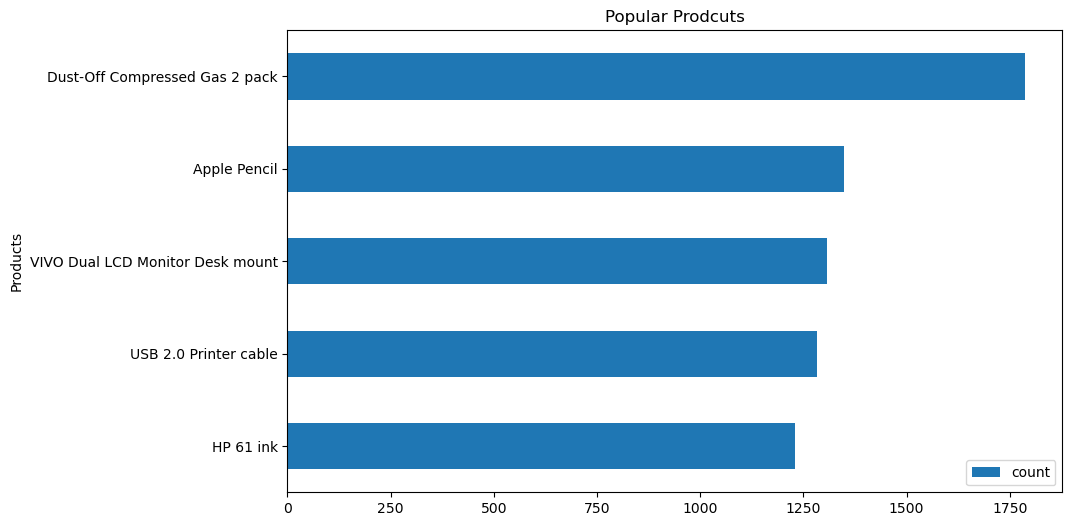

In [84]:
#5 most popular products in transformed dataset
count = teleco_clean.loc[:,:].sum()
pop_item = count.sort_values( ascending = False).head(5)
pop_item = pop_item.to_frame()
pop_item = pop_item.reset_index()
pop_item = pop_item.rename(columns = {'index': 'Products',0: 'count'})

#data visualization
plt.rcParams['figure.figsize'] = (10,6)
ax = pop_item.plot.barh(x = 'Products', y = 'count')
plt.title('Popular Prodcuts')
plt.gca().invert_yaxis()


In [85]:
#c2 code
#association rules with Apriori algorithm
rules = apriori(teleco_clean, min_support= 0.02, use_colnames=True)
rules.head()


,support,itemsets
0,0.050527,(10ft iPHone Charger Cable 2 Pack)
1,0.042528,(3A USB Type C Cable 3 pack 6FT)
2,0.029463,(Anker 2-in-1 USB Card Reader)
3,0.068391,(Anker USB C to HDMI Adapter)
4,0.087188,(Apple Lightning to Digital AV Adapter)


In [86]:
#rules table with lift
rules_table = association_rules(rules, metric='lift', min_threshold=1)
rules_table.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(10ft iPHone Charger Cable 2 Pack),(Dust-Off Compressed Gas 2 pack),0.050527,0.238368,0.023064,0.456464,1.914955,1.0,0.011020,1.401255,0.503221,0.086760,0.286354,0.276610
1,(Dust-Off Compressed Gas 2 pack),(10ft iPHone Charger Cable 2 Pack),0.238368,0.050527,0.023064,0.096756,1.914955,1.0,0.011020,1.051182,0.627330,0.086760,0.048690,0.276610
2,(Dust-Off Compressed Gas 2 pack),(Anker USB C to HDMI Adapter),0.238368,0.068391,0.024397,0.102349,1.496530,1.0,0.008095,1.037830,0.435627,0.086402,0.036451,0.229537
3,(Anker USB C to HDMI Adapter),(Dust-Off Compressed Gas 2 pack),0.068391,0.238368,0.024397,0.356725,1.496530,1.0,0.008095,1.183991,0.356144,0.086402,0.155399,0.229537
4,(VIVO Dual LCD Monitor Desk mount),(Anker USB C to HDMI Adapter),0.174110,0.068391,0.020931,0.120214,1.757755,1.0,0.009023,1.058905,0.521973,0.094465,0.055628,0.213129
5,(Anker USB C to HDMI Adapter),(VIVO Dual LCD Monitor Desk mount),0.068391,0.174110,0.020931,0.306043,1.757755,1.0,0.009023,1.190117,0.462740,0.094465,0.159746,0.213129
6,(Apple Lightning to Digital AV Adapter),(Apple Pencil),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
7,(Apple Pencil),(Apple Lightning to Digital AV Adapter),0.179709,0.087188,0.028796,0.160237,1.837830,1.0,0.013128,1.086988,0.555754,0.120941,0.080026,0.245256
8,(Dust-Off Compressed Gas 2 pack),(Apple Lightning to Digital AV Adapter),0.238368,0.087188,0.024397,0.102349,1.173883,1.0,0.003614,1.016889,0.194486,0.081009,0.016609,0.191083
9,(Apple Lightning to Digital AV Adapter),(Dust-Off Compressed Gas 2 pack),0.087188,0.238368,0.024397,0.279817,1.173883,1.0,0.003614,1.057552,0.162275,0.081009,0.054420,0.191083


### C3

In [87]:
#C3 Support
#top 3 sorted by support metric
top_three_rules = rules_table.sort_values('support', ascending=False).head(3)
top_three_rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
62,(VIVO Dual LCD Monitor Desk mount),(Dust-Off Compressed Gas 2 pack),0.174110,0.238368,0.059725,0.343032,1.439085,1.0,0.018223,1.159314,0.369437,0.169312,0.137421,0.296796
63,(Dust-Off Compressed Gas 2 pack),(VIVO Dual LCD Monitor Desk mount),0.238368,0.174110,0.059725,0.250559,1.439085,1.0,0.018223,1.102008,0.400606,0.169312,0.092566,0.296796
41,(HP 61 ink),(Dust-Off Compressed Gas 2 pack),0.163845,0.238368,0.052660,0.321400,1.348332,1.0,0.013604,1.122357,0.308965,0.150648,0.109018,0.271158


In [88]:
#C3 Lift
#top 3 sorted by lift metric
top_three_rules = rules_table.sort_values('lift', ascending=False).head(3)
top_three_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
85,(VIVO Dual LCD Monitor Desk mount),(SanDisk Ultra 64GB card),0.174110,0.098254,0.039195,0.225115,2.291162,1.0,0.022088,1.163716,0.682343,0.168096,0.140684,0.312015
84,(SanDisk Ultra 64GB card),(VIVO Dual LCD Monitor Desk mount),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
65,(FEIYOLD Blue light Blocking Glasses),(VIVO Dual LCD Monitor Desk mount),0.065858,0.174110,0.022930,0.348178,1.999758,1.0,0.011464,1.267048,0.535186,0.105651,0.210764,0.239939


In [89]:
#C3 Confidence
#top 3 sorted by confidence metric
top_three_rules = rules_table.sort_values('confidence', ascending=False).head(3)
top_three_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(10ft iPHone Charger Cable 2 Pack),(Dust-Off Compressed Gas 2 pack),0.050527,0.238368,0.023064,0.456464,1.914955,1.0,0.011020,1.401255,0.503221,0.086760,0.286354,0.276610
36,(FEIYOLD Blue light Blocking Glasses),(Dust-Off Compressed Gas 2 pack),0.065858,0.238368,0.027596,0.419028,1.757904,1.0,0.011898,1.310962,0.461536,0.099759,0.237201,0.267400
52,(SanDisk Ultra 64GB card),(Dust-Off Compressed Gas 2 pack),0.098254,0.238368,0.040928,0.416554,1.747522,1.0,0.017507,1.305401,0.474369,0.138413,0.233952,0.294127


### C4

  
4. Explain the top three relevant rules generated by the Apriori algorithm. Include a screenshot of the top three relevant rules.

- From the lift metric, the first rule, the lift is 2.29 tells us that SanDisk Ultra 64GB card is 2.29 times more likely to be bought by a customer who also buys VIVO Dual LCD Monitor Desk mount.  The confidence level of .22 shows that out of all transactions that contain VIVO Dual LCD Monitor Desk mount, .22 also contain SanDisk Ultra 64GB card.  The support is .039, calculated by dividing the number of transactions containing SanDisk Ultra 64GB card and VIVO Dual LCD Monitor Desk mount by the total number of transactions.  
- Rule 2, the lift is 2.29.  Telling us that VIVO Dual LCD Monitor Desk mount is 2.29 times more likely to be bought by a customer who also buys SanDisk Ultra 64GB card.  The confidence level of .39 shows that out of all transactions that contain SanDisk Ultra 64GB card, .39 also contain VIVO Dual LCD Monitor Desk mount.  The support is .039, calculated by dividing the number of transactions containing VIVO Dual LCD Monitor Desk mount and SanDisk Ultra 64GB card mount by the total number of transactions.
- Rule 3, the lift is 1.99.  Telling us that VIVO Dual LCD Monitor Desk mount is 1.99 times more like to be bought by a customer show also buys FEIYOLD Blue light Blocking Glasses.  The confidence level of .34 shows that out of all transactions that contain FEIYOLD Blue light Blocking Glasses, also contain VIVO Dual LCD Monitor Desk mount.  The support is .022, calculated by dividing the number of transactions containing VIVO Dual LCD Monitor Desk mount and FEIYOLD Blue light Blocking Glasses by the total number of transactions.

- Evaluator note - If below screenshots do not appear in the ipynb, please refer to the pdf.

- Lift Screenshot
![alt text](image-2.png)

- Confidence Screenshot
![alt text](image-3.png)

- Support Screenshot
![alt text](image-1.png)

## Part IV: Data Summary and Implications

### D.  Summarize your data analysis by doing the following:
1.  Summarize the significance of support, lift, and confidence from the results of the analysis.

    - **Support:**  Support is the frequency of times that an item appears within the dataframe.  This is used to measure the popularity of an item.  According to this analysis, the two items with the most support are the VIVO Dual LCD Monitor Desk mount and Dust-Off Compressed Gas 2 pack. 

    - **Lift:**  Lift measures how much more likely two items are purchased together compared to random chance.  According to this analysis, the two items with the highest lift value are the VIVO Dual LCD Monitor Desk mount and SanDisk Ultra 64GB card.  Meaning, customers who bought the VIVO Dual LCD Monitor Desk mount are 2.29 times more likely to buy a SanDisk Ultra 64GB card.  Lift values > 1 tend to mean that consequent would likely be purchased if antecedent (x) is purchased and consequently lift values < 1 would indicate that the items are unlikely to be purchased.  

    - **Confidence:**  Confidence measures the likelyhood that item Y is purchased when item X is purchased.  According to this analysis, the two items with the highest confidence value are the 10ft iPHone Charger Cable 2 pack and the Dust-Off Compressed Gas 2 Pack.  The confidence of .456 or 46%, means there is a 46% chance customers who bought 10ft iPHone Charger Cable 2 pack will also buy the Dust-Off Compressed Gas 2 Pack.  A downside to the confidence metric is that incorrect conclusions can be drawn based on misrepresentation of the importance of an association

2.  Discuss the practical significance of your findings from the analysis.

    - The practical significance of the findings from the analysis are beneficial to the company.  Patterns were able to be identifed using MBA which will help stakeholders make informed business decisions and better able to target products and marketing campaigns for customers, resulting in better profits for the company in the long term.   


3.  Recommend a course of action for the real-world organizational situation from part A1 based on the results from part D1.

    - The recommended course of action based off of this analysis would be to create bundles or special offers for the products identified in this analysis.  The company could also create marketing materials sucsh as adverstisements or emails campaigns featuring these items to help increase sales.  


## Part V: Demonstration

### E.  Provide a Panopto video recording that includes the presenter and a vocalized demonstration of the functionality of the code used for the analysis of the programming environment.



- https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=8e1e787c-1271-4534-8528-b485015e73f2

### F.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.
    None used.

### G.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip 

    GeeksforGeeks. (2025, July 23). Market basket analysis in data mining . GeeksforGeeks. https://www.geeksforgeeks.org/data-science/market-basket-analysis-in-data-mining/ 

    Deniran, O. H. (2023, November 27). Boosting sales with data: The Power of Market Basket Analysis in Retail | by Oluwakemi Helen deniran | medium. https://medium.com/@chemistry8526/boosting-sales-with-data-the-power-of-market-basket-analysis-in-retail-c79cc10a14df 
     
    